<a href="https://colab.research.google.com/github/Akshay-Git-2/Brest-cancer-detection/blob/main/Breast_Cancer_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

df = pd.read_csv('/content/Brest_data.csv')

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
# Remove unnecessary columns
df = df.drop(columns=['id', 'Unnamed: 32'])

print("New Shape:", df.shape)

df.head()

New Shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
print(df.isnull().sum())

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['diagnosis'] = le.fit_transform(df['diagnosis'])

print(df['diagnosis'].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [7]:
X = df.drop('diagnosis', axis=1)

y = df['diagnosis']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (569, 30)
y Shape: (569,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (455, 30)
Testing Shape: (114, 30)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled Shape:", X_train_scaled.shape)
print("X_test_scaled Shape:", X_test_scaled.shape)

X_train_scaled Shape: (455, 30)
X_test_scaled Shape: (114, 30)


In [10]:
print(X_train_scaled[:2])

[[ 0.51855873  0.89182579  0.4246317   0.38392544 -0.97474371 -0.6897715
  -0.68858645 -0.39817525 -1.0391547  -0.82505632 -0.10931776 -0.05597554
  -0.21009621 -0.01591326 -1.00518399 -0.91194199 -0.66281588 -0.65256108
  -0.70188911 -0.27539357  0.5797977   1.31324246  0.46690813  0.44598271
  -0.59615478 -0.63472223 -0.6102273  -0.23574392  0.05456632  0.02183673]
 [-0.51636409 -1.63971029 -0.54134872 -0.54296133  0.47621906 -0.63183382
  -0.60428117 -0.30307491  0.52154309 -0.4545229  -0.60437796 -1.00104604
  -0.585429   -0.49345379  0.40321201 -0.76817328 -0.47918722  0.11450848
  -0.14295076 -0.57739773 -0.58245895 -1.69029101 -0.61193429 -0.58701354
   0.27358196 -0.81484449 -0.71266641 -0.32320788 -0.13757624 -0.90440164]]


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

# Input Layer
model.add(Dense(64, activation='relu', input_shape=(30,)))
model.add(Dropout(0.2))

# Hidden Layer
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# Hidden Layer
model.add(Dense(16, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7225 - loss: 0.5881 - val_accuracy: 0.9341 - val_loss: 0.3719
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9231 - loss: 0.3339 - val_accuracy: 0.9560 - val_loss: 0.2065
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9423 - loss: 0.1917 - val_accuracy: 0.9451 - val_loss: 0.1479
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9698 - loss: 0.1216 - val_accuracy: 0.9560 - val_loss: 0.1183
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9698 - loss: 0.1190 - val_accuracy: 0.9670 - val_loss: 0.1086
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9753 - loss: 0.0901 - val_accuracy: 0.9560 - val_loss: 0.0990
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9780 - loss: 0.0789 - val_accuracy: 0.9560 - val_loss: 0.0933
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9835 - loss: 0.0760 - val_accuracy: 0.9560 - val_loss

In [13]:
loss, accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9824561476707458


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict probabilities
y_prob = model.predict(X_test_scaled)

# Convert probabilities to 0 or 1
y_pred = (y_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Accuracy : 0.9825
Precision: 1.0
Recall   : 0.9524
F1 Score : 0.9756


<Figure size 600x600 with 0 Axes>

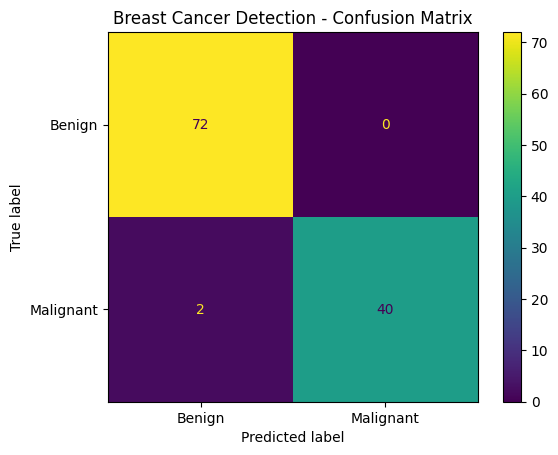

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign","Malignant"]
)

plt.figure(figsize=(6,6))
disp.plot()
plt.title("Breast Cancer Detection - Confusion Matrix")
plt.show()

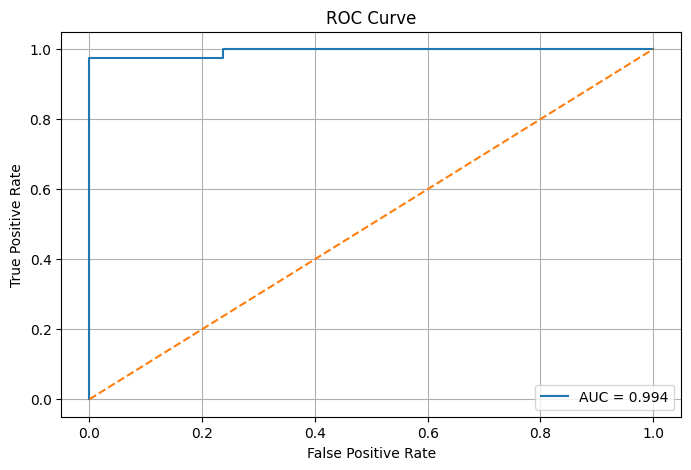

AUC Score: 0.9943783068783068


In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

print("AUC Score:", roc_auc)

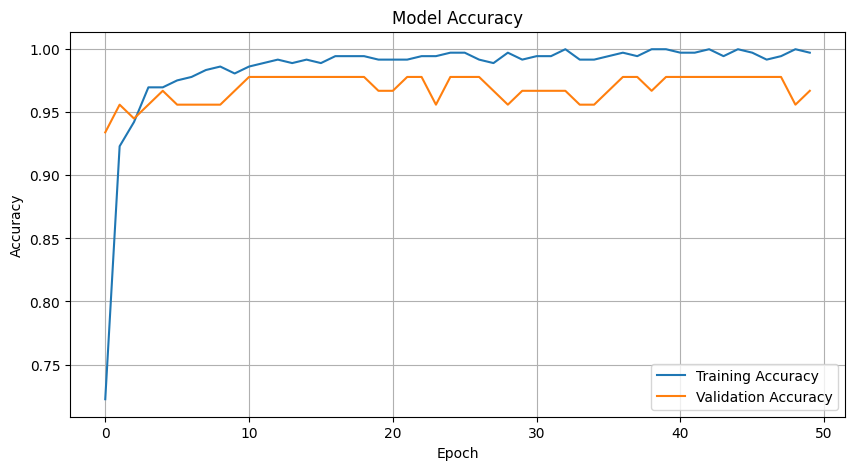

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
model.save("breast_cancer_nn.keras")

import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model Saved Successfully")

Model Saved Successfully


In [19]:
import pandas as pd

sample = pd.DataFrame([[
    11.5,14.0,73.0,400.0,0.085,
    0.050,0.020,0.015,0.170,0.055,
    0.200,0.800,1.500,20.0,0.005,
    0.010,0.010,0.005,0.015,0.002,
    13.0,18.0,85.0,500.0,0.110,
    0.120,0.080,0.050,0.250,0.070
]], columns=X.columns)

sample_scaled = scaler.transform(sample)
prediction = model.predict(sample_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [20]:
import numpy as np

benign_sample = pd.DataFrame([[
    11.5, 14.0, 73.0, 400.0, 0.085,
    0.050, 0.020, 0.015, 0.170, 0.055,
    0.200, 0.800, 1.500, 20.0, 0.005,
    0.010, 0.010, 0.005, 0.015, 0.002,
    13.0, 18.0, 85.0, 500.0, 0.110,
    0.120, 0.080, 0.050, 0.250, 0.070
]])

# Apply same scaler used during training
benign_sample = scaler.transform(benign_sample)

prediction = model.predict(benign_sample, verbose=0)

malignant_prob = float(prediction[0][0]) * 100
benign_prob = (1 - float(prediction[0][0])) * 100

if prediction[0][0] > 0.5:
    result = "⚠️ Malignant Breast Cancer"
else:
    result = "✅ Benign Breast Tumor"

print("="*50)
print("BREAST CANCER DETECTION RESULT")
print("="*50)
print("Prediction:", result)
print(f"Benign Probability: {benign_prob:.2f}%")
print(f"Malignant Probability: {malignant_prob:.2f}%")
print("="*50)

BREAST CANCER DETECTION RESULT
Prediction: ✅ Benign Breast Tumor
Benign Probability: 100.00%
Malignant Probability: 0.00%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [21]:
import numpy as np

malignant_sample = pd.DataFrame([[
    20.0, 25.0, 130.0, 1200.0, 0.120,
    0.250, 0.300, 0.150, 0.220, 0.080,
    1.000, 1.500, 7.000, 120.0, 0.010,
    0.050, 0.060, 0.030, 0.030, 0.005,
    25.0, 35.0, 170.0, 1800.0, 0.180,
    0.500, 0.700, 0.250, 0.400, 0.120
]])

# Apply same scaler used during training
malignant_sample = scaler.transform(malignant_sample)

prediction = model.predict(malignant_sample, verbose=0)

malignant_prob = float(prediction[0][0]) * 100
benign_prob = (1 - float(prediction[0][0])) * 100

if prediction[0][0] > 0.5:
    result = "⚠️ Malignant Breast Cancer"
else:
    result = "✅ Benign Breast Tumor"

print("="*50)
print("BREAST CANCER DETECTION RESULT")
print("="*50)
print("Prediction:", result)
print(f"Benign Probability: {benign_prob:.2f}%")
print(f"Malignant Probability: {malignant_prob:.2f}%")
print("="*50)

BREAST CANCER DETECTION RESULT
Prediction: ⚠️ Malignant Breast Cancer
Benign Probability: 0.00%
Malignant Probability: 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
